# Computer Vision (Image operators and filters)

By the end of this lab, you will get hands on experience working with:

*   Image Handling
*   Image Manipulation
*   Histogram and Histogram Equalization
*   Basic filtering techniques

<!-- ### **Remember this is a graded exercise.** -->

**Reminder**:

*   For every plot, make sure you provide appropriate titles, axis labels, legends, wherever applicable.
*   Add sufficient comments and explanations wherever necessary.

---


In [1]:
import numpy as np
from matplotlib import pyplot as plt
from skimage import data, exposure, filters, io, morphology

# Channels and color spaces

### **Exercise: Image Creation and Color Manipulation**

*   Create a 100 x 100 image for each of the below visualization

![image.png](attachment:image.png)

*   Visualize the created images in a 1 x 3 subplot using matplotlib.


In [2]:
img1 = np.zeros((100, 100), dtype=np.uint8)
img2 = np.zeros((100, 100), dtype=np.uint8)
img3 = np.zeros((100, 100), dtype=np.uint8)

In [3]:
img1[:, 50:] = 255
img2[50:, :] = 255
img3[:50, :50] = 255

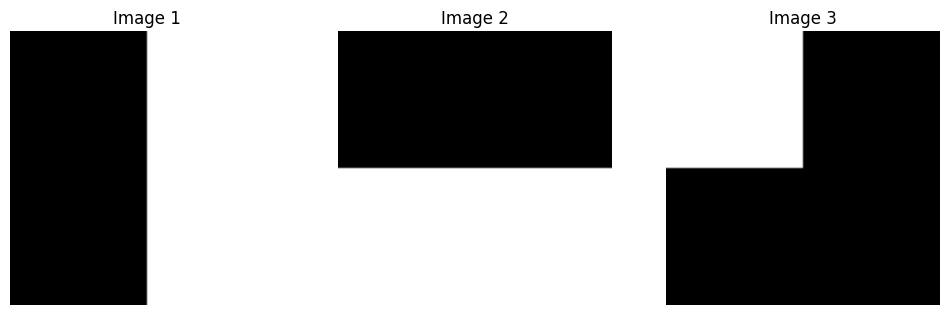

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))

axes[0].imshow(img1, cmap='gray')
axes[0].set_title('Image 1')
axes[0].axis('off')

axes[1].imshow(img2, cmap='gray')
axes[1].set_title('Image 2')
axes[1].axis('off')

axes[2].imshow(img3, cmap='gray')
axes[2].set_title('Image 3')
axes[2].axis('off')

plt.show()

*   Use the above three images to create the following image

![image-2.png](attachment:image-2.png)
*Hint: Remember channels and color spaces*

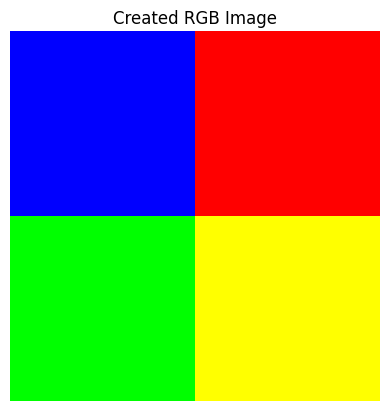

In [5]:
created_image = np.zeros((100, 100, 3), dtype=np.uint8)
created_image[:, :, 0] = img1
created_image[:, :, 1] = img2
created_image[:, :, 2] = img3

plt.imshow(created_image)
plt.title('Created RGB Image')
plt.axis('off')
plt.show()


### **Exercise: Color Manipulation**

*   Read the image 'sillas.jpg' from the images folder

![image.png](attachment:image.png)

*   Extract individual channels and plot them using matplotlib subplot.



In [6]:
!git clone https://github.com/RamiSaad93/lab-computer-vision.git

fatal: destination path 'lab-computer-vision' already exists and is not an empty directory.


In [7]:
sillas = io.imread("lab-computer-vision/images/sillas.jpg")

In [8]:
red_channel = sillas[:, :, 0]
green_channel = sillas[:, :, 1]
blue_channel = sillas[:, :, 2]

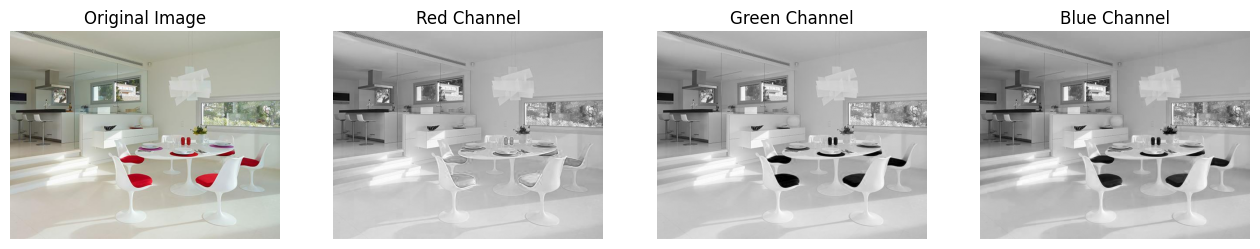

In [9]:
fig, axes = plt.subplots(1, 4, figsize=(16, 4))

axes[0].imshow(sillas)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(red_channel, cmap='gray')
axes[1].set_title('Red Channel')
axes[1].axis('off')

axes[2].imshow(green_channel, cmap='gray')
axes[2].set_title('Green Channel')
axes[2].axis('off')

axes[3].imshow(blue_channel, cmap='gray')
axes[3].set_title('Blue Channel')
axes[3].axis('off')

plt.show()

*   The color **red** looks too bright for the eyes. Isn't it?? Lets change the color and see how it appears.
    *    Create a new image where everything that is **'red' is changed to 'blue'**.
*   Visualize the original image and the created image using matplotlib subplot.

In [10]:
sillas_blue = sillas.copy()

In [11]:
red_mask = ((sillas[:, :, 0] > 150) &
            (sillas[:, :, 1] < 120) &
            (sillas[:, :, 2] < 120))

sillas_blue[red_mask] = [0, 0, 255]

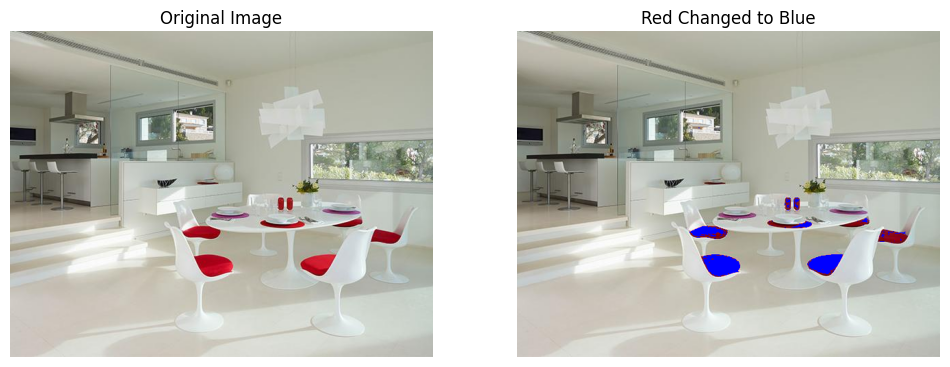

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(sillas)
axes[0].set_title('Original Image')
axes[0].axis('off')

axes[1].imshow(sillas_blue)
axes[1].set_title('Red Changed to Blue')
axes[1].axis('off')

plt.show()

# Image Manipulation

### **Exercise: Image Operators**

*   You can find images 'model.png' and 'coat.png' in the images folder (First two images of the below visualization). Your task is to create an image from the given two images such a way that the model is wearing the coat (Third image in the visualization).
*   You can also find different textures in the images folder. Your task is to change the coat texture to any one of the given textures.
*   Visualize the images similar to the given visualization.

*Hint: Think masks!!!*

![image.png](attachment:image.png)

In [13]:
model = io.imread('lab-computer-vision/images//model.png')
coat = io.imread('lab-computer-vision/images//coat.png')
texture = io.imread('lab-computer-vision/images//texture3.jpg')

In [15]:
# Keep RGB channels only.
model_rgb = model[:, :, :3]
coat_rgb = coat[:, :, :3]
texture_rgb = texture[:, :, :3]

coat_rgb

array([[[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       ...,

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]],

       [[0, 0, 0],
        [0, 0, 0],
        [0, 0, 0],
        ...,
        [0, 0, 0],
        [0, 0, 0],
        [0, 0, 0]]], dtype=uint8)

In [16]:
# Create a mask for the coat.
# The coat image has black background, so pixels brighter than black are treated as coat pixels.
coat_mask = np.any(coat_rgb > 20, axis=2)

In [17]:
# Tile the texture so it has the same height and width as the coat image.
h, w = coat_rgb.shape[:2]
texture_tiled = np.tile(
    texture_rgb,
    (h // texture_rgb.shape[0] + 1, w // texture_rgb.shape[1] + 1, 1)
)
texture_tiled = texture_tiled[:h, :w, :]

In [18]:
# Apply the texture only on the coat area.
textured_coat = coat_rgb.copy()
textured_coat[coat_mask] = texture_tiled[coat_mask]

In [19]:
# Put the textured coat on the model using the coat mask.
model_with_coat = model_rgb.copy()
model_with_coat[coat_mask] = textured_coat[coat_mask]

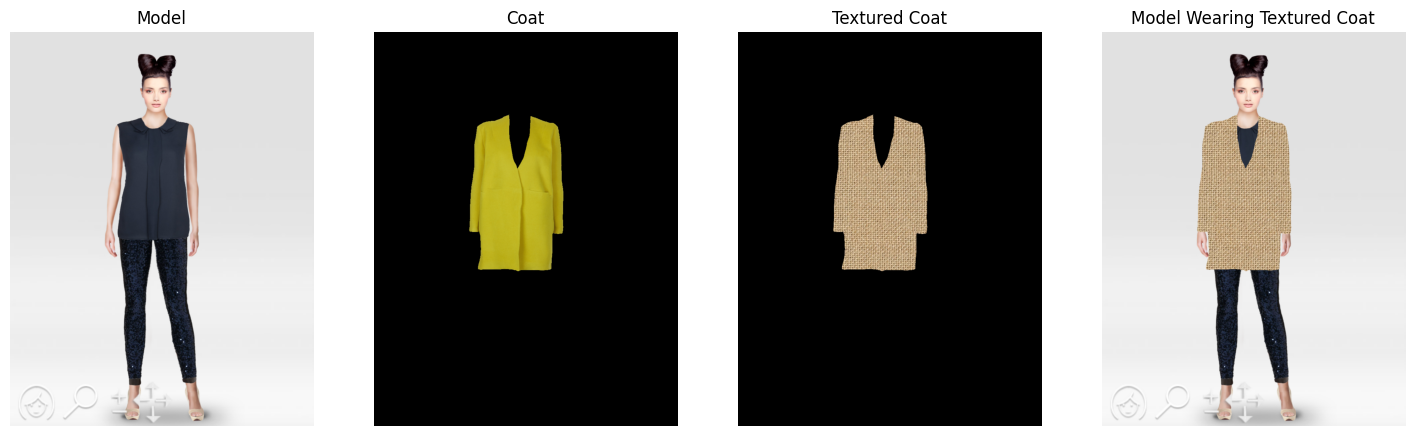

In [20]:
# Visualize the result.
fig, axes = plt.subplots(1, 4, figsize=(18, 6))

axes[0].imshow(model_rgb)
axes[0].set_title('Model')
axes[0].axis('off')

axes[1].imshow(coat_rgb)
axes[1].set_title('Coat')
axes[1].axis('off')

axes[2].imshow(textured_coat)
axes[2].set_title('Textured Coat')
axes[2].axis('off')

axes[3].imshow(model_with_coat)
axes[3].set_title('Model Wearing Textured Coat')
axes[3].axis('off')

plt.show()


# Contrast Enhancement

### **Exercise: Histogram Computation**

*   Read the **'astronaut' image** from data module.
*   Convert the image to grayscale.
*   Compute the **histogram of the image.** *Hint: histogram function is available in skimage.exposure package*
*   Plot the histogram using matplotlib plot.




In [22]:
import cv2

In [23]:
# Read astronaut image
astronaut = data.astronaut()

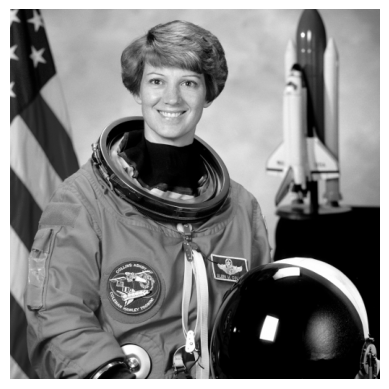

In [24]:
# Convert RGB to grayscale
astronaut_gray = cv2.cvtColor(astronaut, cv2.COLOR_RGB2GRAY)

# Show grayscale image
plt.imshow(astronaut_gray, cmap="gray")
plt.axis("off")
plt.show()


In [27]:
hist, bin_centers = exposure.histogram(astronaut_gray, nbins=256, source_range='image', normalize=False, channel_axis=None)

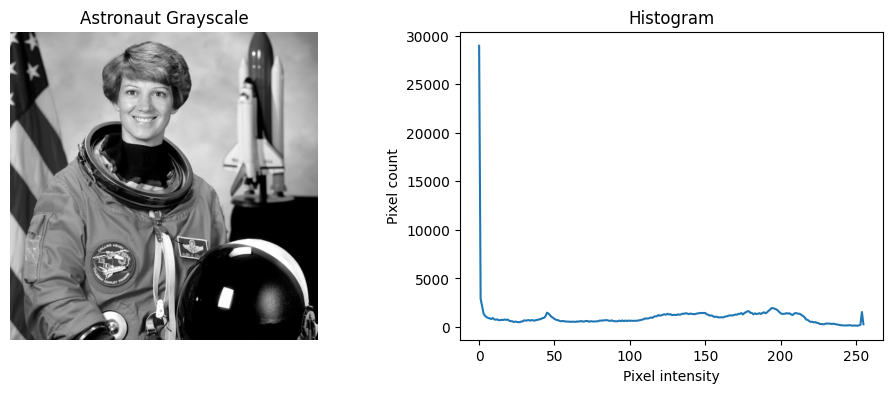

In [28]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(astronaut_gray, cmap="gray")
axes[0].set_title("Astronaut Grayscale")
axes[0].axis("off")

axes[1].plot(bin_centers, hist)
axes[1].set_title("Histogram")
axes[1].set_xlabel("Pixel intensity")
axes[1].set_ylabel("Pixel count")

plt.show()

*   Change the bin count to 8 and compute the histogram of the image and plot the computed histogram using matplotlib plot.

In [30]:
hist, bin_centers = exposure.histogram(astronaut_gray, nbins=8, source_range='image', normalize=False, channel_axis=None)

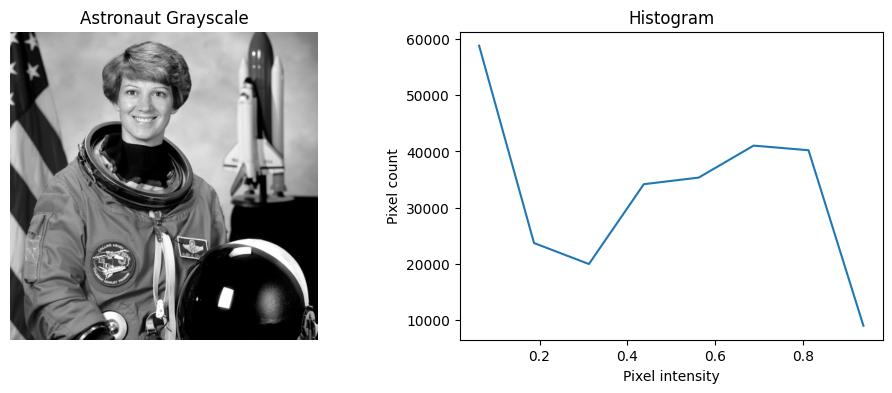

In [31]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].imshow(astronaut_gray, cmap="gray")
axes[0].set_title("Astronaut Grayscale")
axes[0].axis("off")

axes[1].plot(bin_centers, hist)
axes[1].set_title("Histogram")
axes[1].set_xlabel("Pixel intensity")
axes[1].set_ylabel("Pixel count")

plt.show()



*   What happens when you change the bin count? Does your inference change based on the bin count? If yes, then how do you define the correct bin count.
*   What happens when the bin count is very low and what happens when it is very high?



**Solution**

*(Double-click or enter to edit)*

...


*   Compute histogram of the color image (without converting it to grayscale).
*   Plot the total histogram and also histogram for each channel (show it in a single plot with differnt legends for each histogram).


In [32]:
hist_total, bins_total = exposure.histogram(astronaut)

/usr/local/lib/python3.12/dist-packages/skimage/_shared/utils.py:445: UserWarning: This might be a color image. The histogram will be computed on the flattened image. You can instead apply this function to each color channel, or set channel_axis.
  return func(*args, **kwargs)


In [33]:
hist_r, bins_r = exposure.histogram(astronaut[:, :, 0])
hist_g, bins_g = exposure.histogram(astronaut[:, :, 1])
hist_b, bins_b = exposure.histogram(astronaut[:, :, 2])

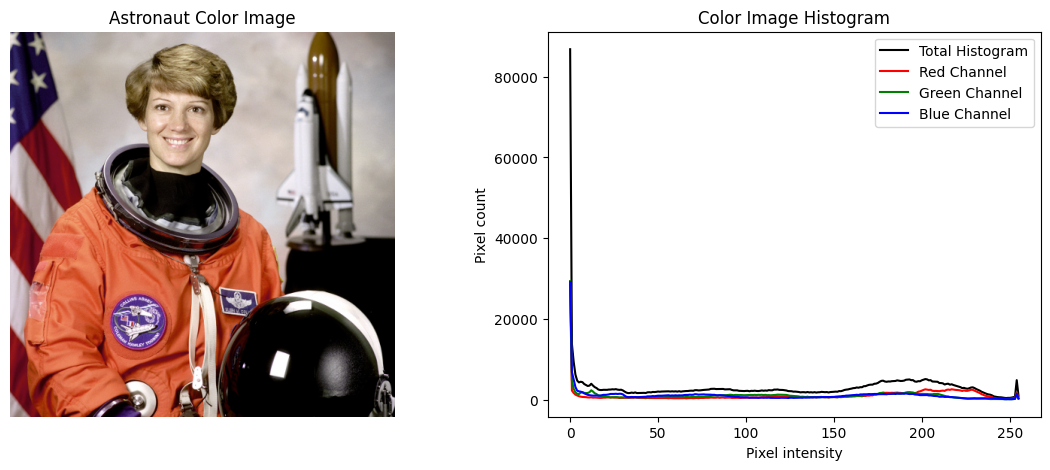

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].imshow(astronaut)
axes[0].set_title("Astronaut Color Image")
axes[0].axis("off")

axes[1].plot(bins_total, hist_total, color="black", label="Total Histogram")
axes[1].plot(bins_r, hist_r, color="red", label="Red Channel")
axes[1].plot(bins_g, hist_g, color="green", label="Green Channel")
axes[1].plot(bins_b, hist_b, color="blue", label="Blue Channel")

axes[1].set_title("Color Image Histogram")
axes[1].set_xlabel("Pixel intensity")
axes[1].set_ylabel("Pixel count")
axes[1].legend()

plt.show()

### **Exercise: Histogram Equalization**

*   Read 'aquatermi_lowcontrast.jpg' image from the images folder.
*   Compute the histogram of the image.
*   Perform histogram equalization of the image to enhance the contrast. *Hint: Use equalize_hist function available in skimage.exposure*
*   Also compute histogram of the equalized image.
*   Use 2 x 2 subplot to show the original image and the enhanced image along with the corresponding histograms.



In [36]:
img = io.imread("lab-computer-vision/images//aquatermi_lowcontrast.jpg")

In [41]:
img_gray = cv2.cvtColor(img, cv2.COLOR_RGB2GRAY)

In [43]:
hist_original, bins_original = exposure.histogram(img_gray)

In [44]:
img_equalized = exposure.equalize_hist(img_gray)

In [45]:
hist_equalized, bins_equalized = exposure.histogram(img_equalized)

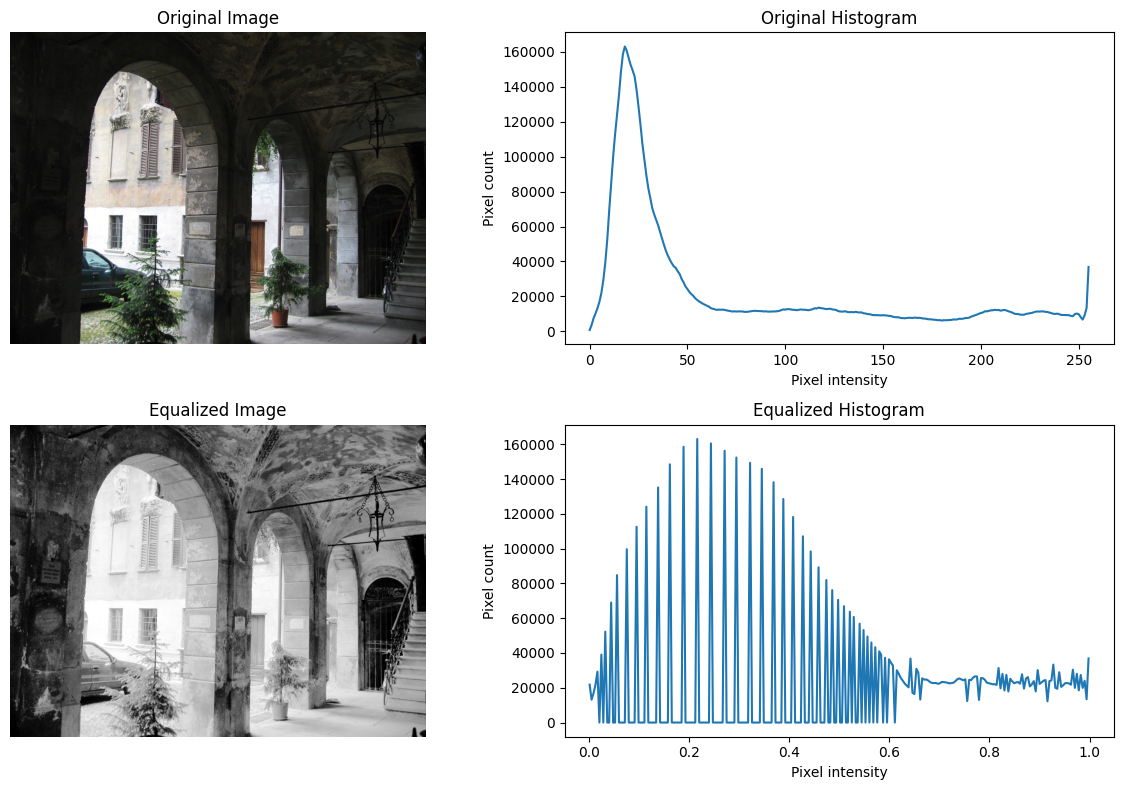

In [48]:
# Plot 2 x 2
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

axes[0, 0].imshow(img, cmap="gray")
axes[0, 0].set_title("Original Image")
axes[0, 0].axis("off")

axes[0, 1].plot(bins_original, hist_original)
axes[0, 1].set_title("Original Histogram")
axes[0, 1].set_xlabel("Pixel intensity")
axes[0, 1].set_ylabel("Pixel count")

axes[1, 0].imshow(img_equalized, cmap="gray")
axes[1, 0].set_title("Equalized Image")
axes[1, 0].axis("off")

axes[1, 1].plot(bins_equalized, hist_equalized)
axes[1, 1].set_title("Equalized Histogram")
axes[1, 1].set_xlabel("Pixel intensity")
axes[1, 1].set_ylabel("Pixel count")

plt.tight_layout()
plt.show()


*   The above function in skimage.exposure uses cdf and interpolation technique to normalize the histogram. How is it different from linear contrast stretch?


**Solution**

*(Double-click or enter to edit)*

...

### **Exercise: Linear Contrast Stretch**

*   Write a function to compute the linear contrast stretch (Do not use an inbuilt function).
*   Provide grayscale image array and bin count as parameters to the function and return the enhanced image array.
*   Use a 2 x 2 plot to visualize the original image, histogram, enhanced image and the corresponding histogram.



# Filters

### **Exercise: Mean Filter**

*   Load the **coins** image from the data module.
*   Define a disk structuring element (selem) of radius 20. *Hint: Structuring elements are defined in the skimage.morphology module*
*   Use mean filter using the created selem. *Hint: The mean filter is available in skimage.filters.rank module*
*   Increase the radius of the selem by 10 and apply the mean filter.
*   Reduce the radius of the selem by 10 and apply the mean filter.
*   Visualize all the smoothened images along with the original image.




*   Use different selem (square, rectangle, star, diamond) to view the behaviour of the mean filter (It is not necessary to repeat with different sizes; it is sufficient to show the one with optimal parameter).
*   Create a 2 x n subplot to show the selem in the first row and the corresponding smoothened image in the second row.

*   How does changing the radius of disk affect the smoothing functionality?

**Solution**

*(Double-click or enter to edit)*

...


*   What is the observed behaviour with difference in the structuring element?



**Solution**

*(Double-click or enter to edit)*

...



*   What is the difference between mean filter and gaussian filter?
*   Where do you use mean filters and where do you use gaussian filters?



**Solution**

*(Double-click or enter to edit)*

...